<a href="https://colab.research.google.com/github/PratyushMaharana/simulation-and-plotting/blob/main/sims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/nicolasloizeau/video-spectrogram.git#egg=video-spectrogram

  Cloning https://github.com/nicolasloizeau/video-spectrogram.git to /tmp/pip-install-8sn6ymj1/video-spectrogram_8be734b891724fe19dac10e83312a94d
  Running command git clone --filter=blob:none --quiet https://github.com/nicolasloizeau/video-spectrogram.git /tmp/pip-install-8sn6ymj1/video-spectrogram_8be734b891724fe19dac10e83312a94d
  Resolved https://github.com/nicolasloizeau/video-spectrogram.git to commit f6bb832f3651f1511dea0e116b82a6f605e1f877
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!video-spectrogram /content/Chilean_Tinamou10.mp3 -mf 2000 -fps 30 -plt

Namespace(file='/content/Chilean_Tinamou10.mp3', window_lenght=10, fps=30, maxfreq=2000.0, prec=0.05, width=800, height=600, colormap='inferno', max_video_lenght=10000, bar_color='white', matplotlib=True, logoffset=1e-06)
fourier transform...
saving the frames...
100% 515/515 [04:25<00:00,  1.94it/s]
generating the video...
MoviePy - Building video output.mp4.
MoviePy - Writing audio in outputTEMP_MPY_wvf_snd.mp3
MoviePy - Done.
MoviePy - Writing video output.mp4

MoviePy - Done !
MoviePy - video ready output.mp4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 3.1 MB/s eta 0:00:00
Optimizing initial conditions...
loss: 0.0002629304
loss: 0.00018203743
loss: 0.00015419615
loss: 0.000122293
loss: 0.000108273256
loss: 9.992368e-05
loss: 9.473003e-05
loss: 9.146185e-05
loss: 8.852717e-05
loss: 8.643746e-05
loss: 8.478254e-05
loss: 8.35547e-05
loss: 8.2588645e-05
loss: 8.181757e-05
loss: 8.090027e-05
loss: 8.014299e-05
loss: 7.961773e-05
loss: 7.924032e-05
loss: 7.872421e-05
loss: 7.847705e-05
loss: 7.8183024e-05
loss: 7.804244e-05
loss: 7.777085e-05
loss: 7.758557e-05
loss: 7.742479e-05
loss: 7.734922e-05
loss: 7.72293e-05
loss: 7.712008e-05
loss: 7.703829e-05
loss: 7.6963464e-05
loss: 7.690432e-05
loss: 7.68574e-05
loss: 7.681008e-05
loss: 7.677964e-05
loss: 7.675923e-05
loss: 7.674193e-05
loss: 7.672476e-05
loss: 7.670813e-05
loss: 7.669283e-05
loss: 7.6678836e-05
loss: 7.666741e-05
loss: 7.665785e-05
Optimization complete.


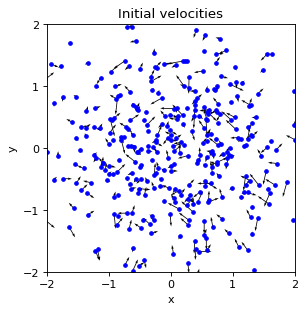

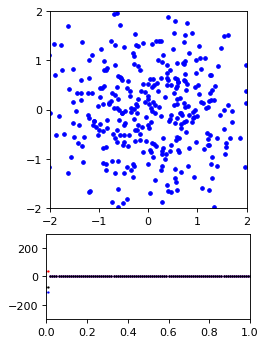

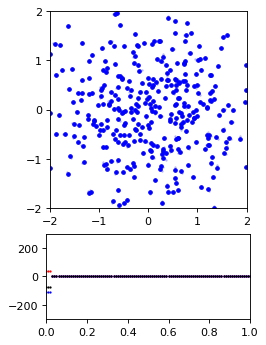

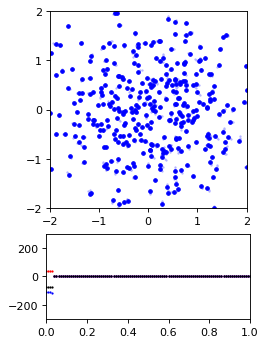

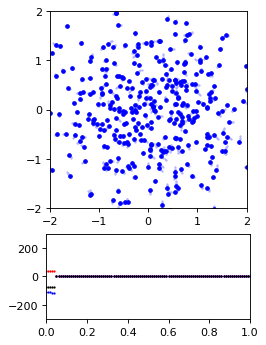

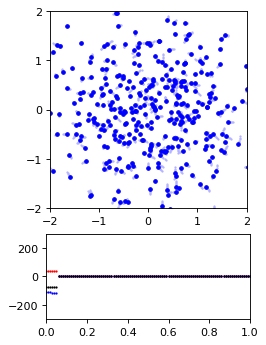

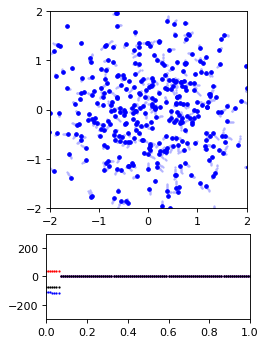

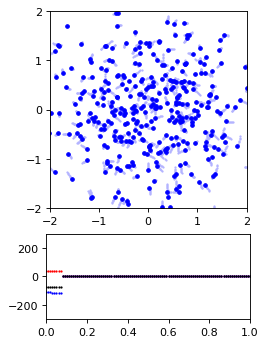

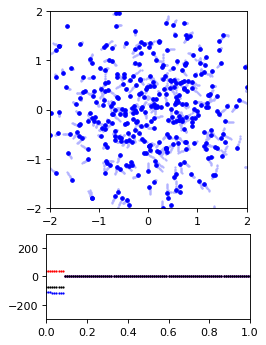

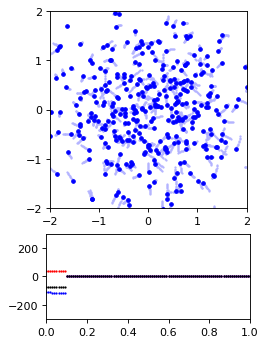

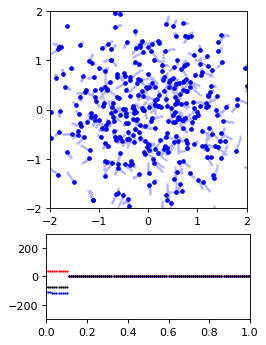

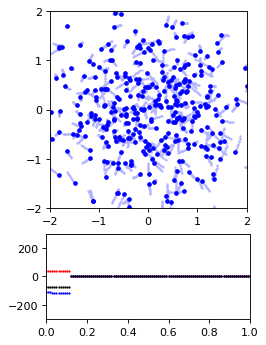

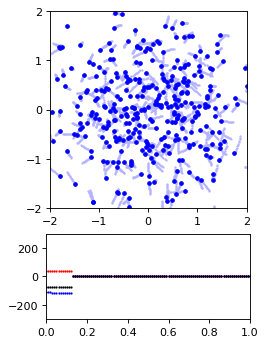

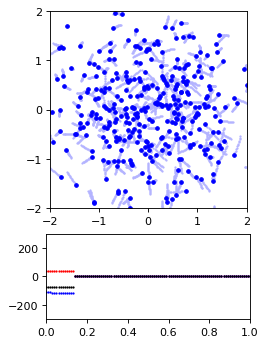

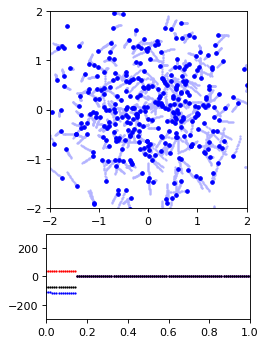

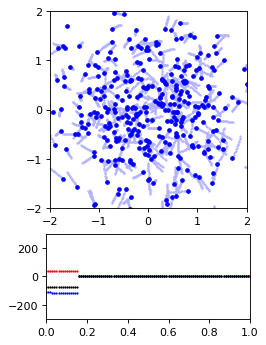

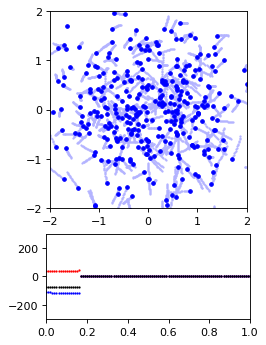

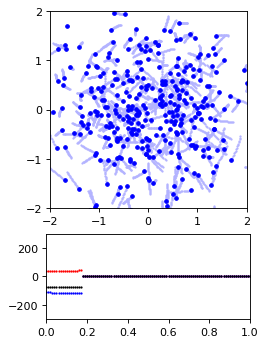

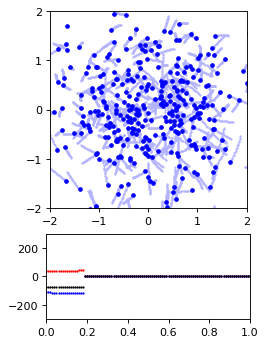

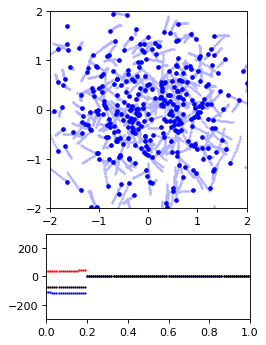

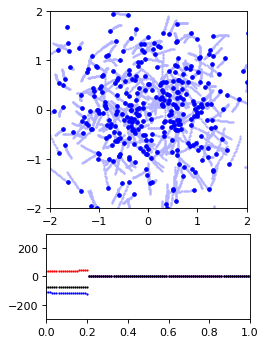

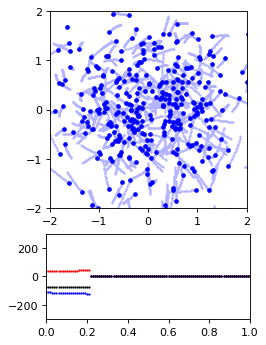

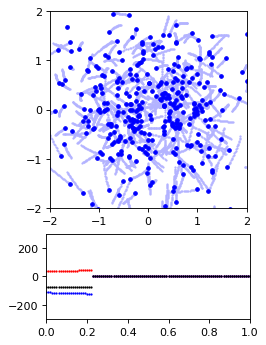

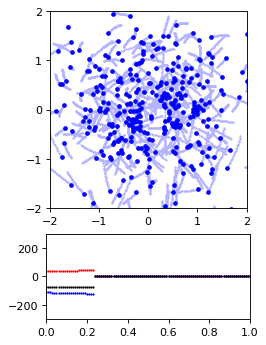

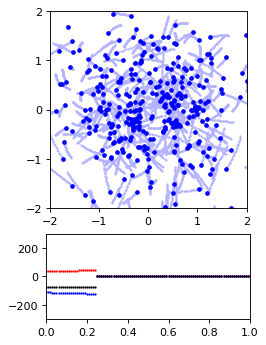

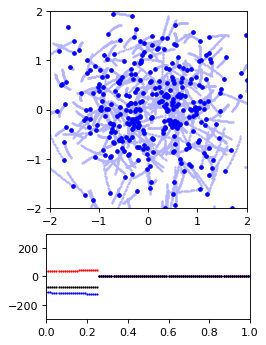

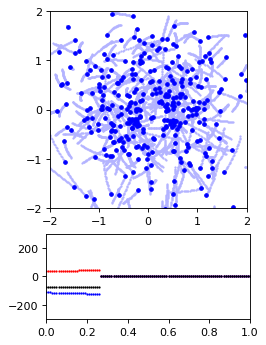

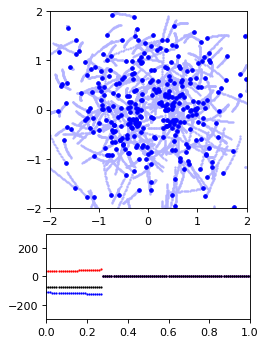

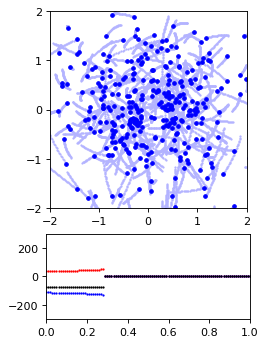

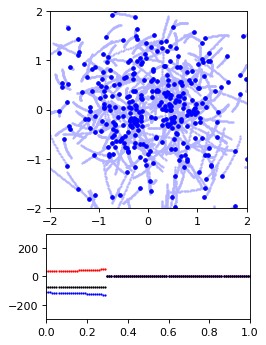

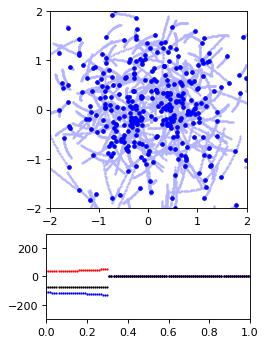

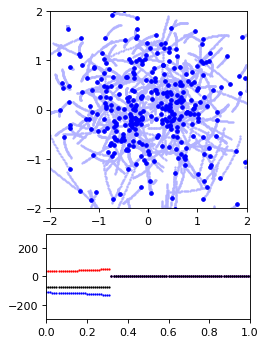

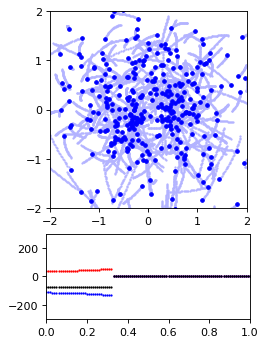

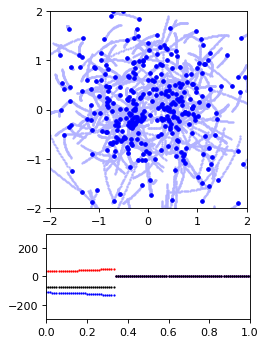

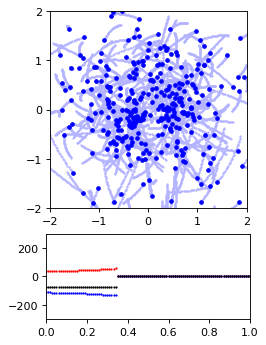

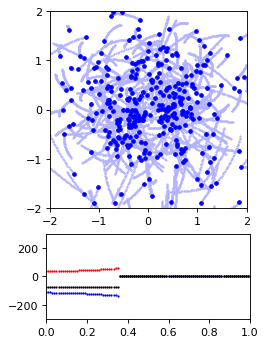

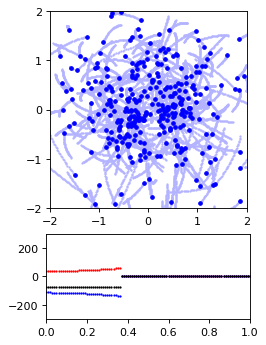

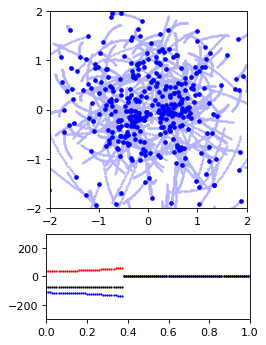

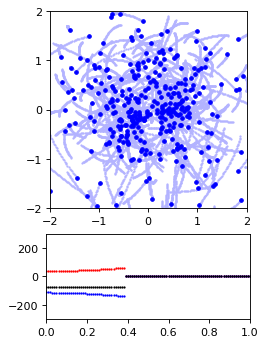

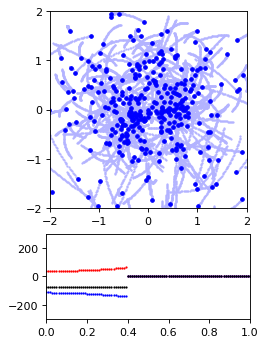

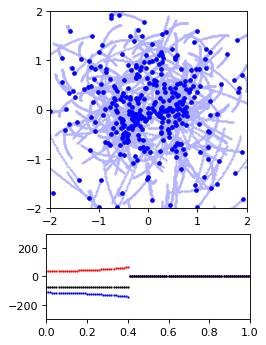

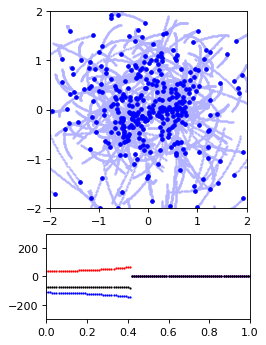

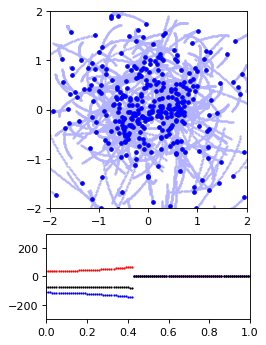

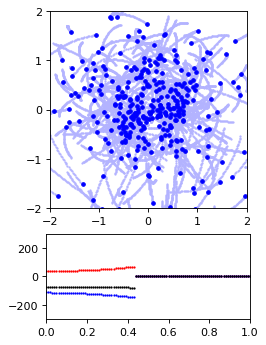

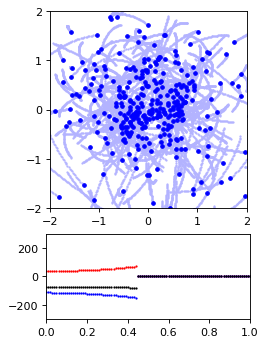

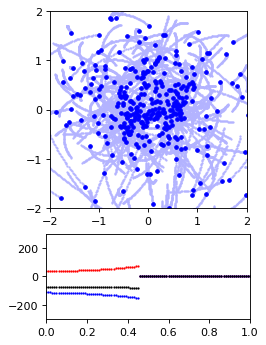

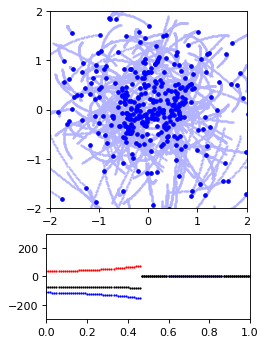

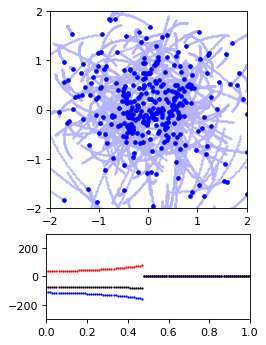

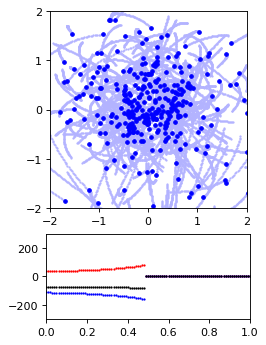

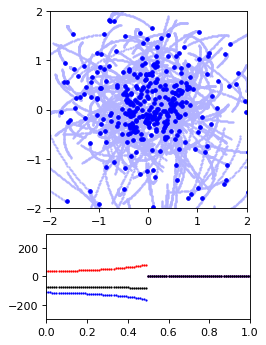

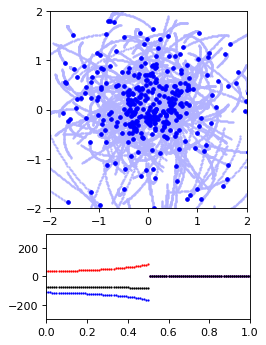

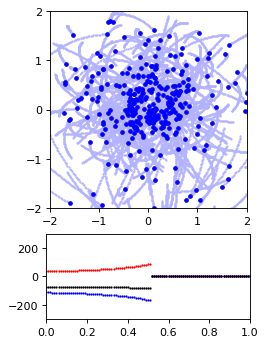

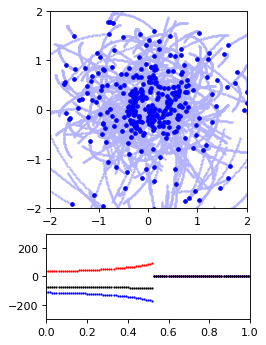

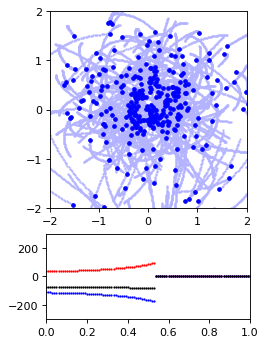

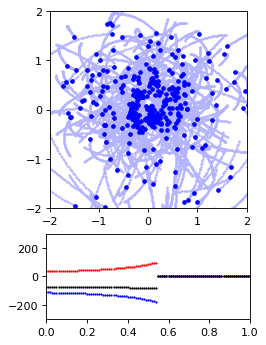

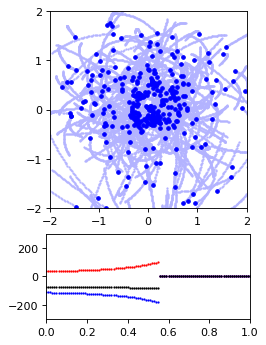

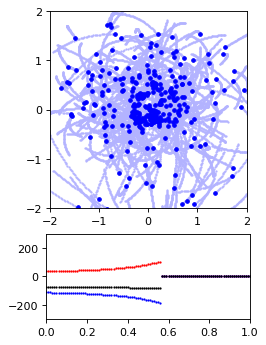

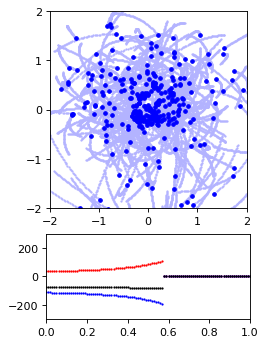

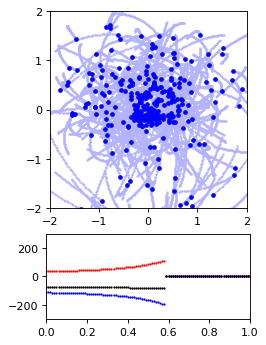

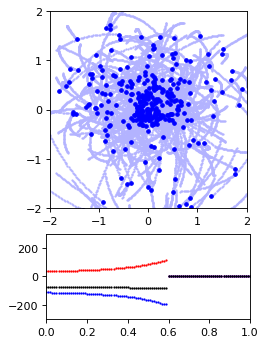

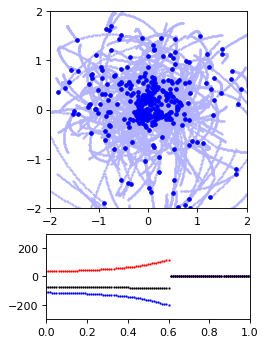

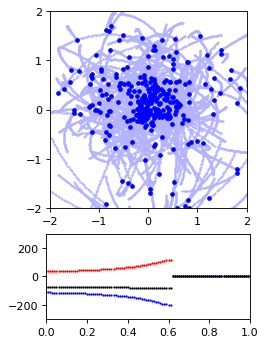

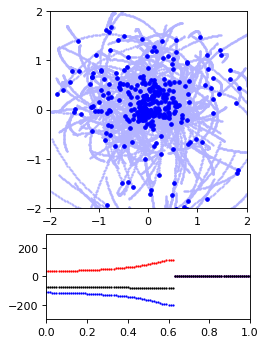

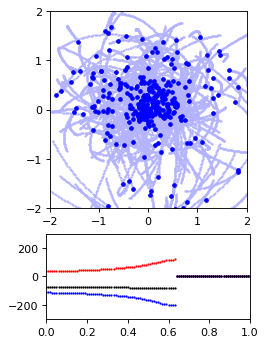

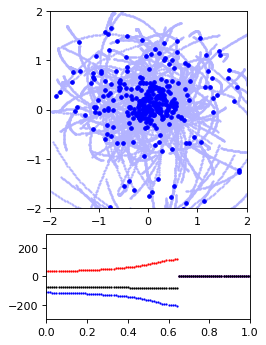

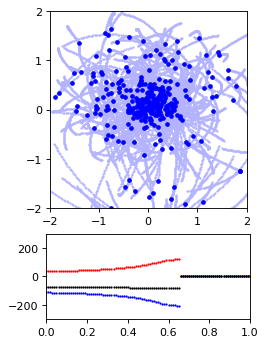

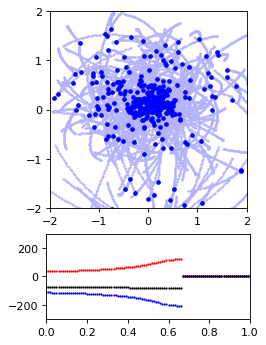

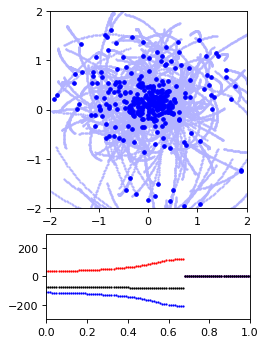

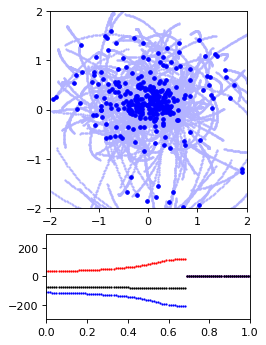

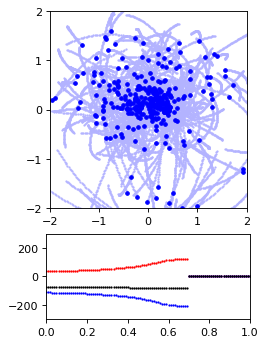

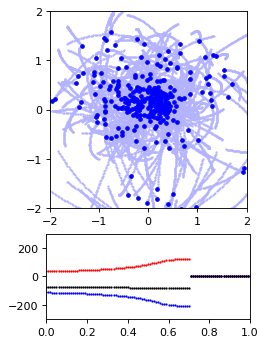

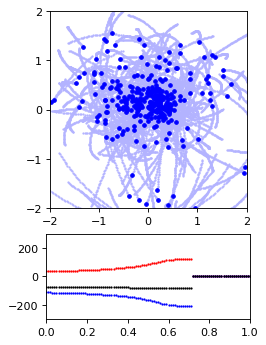

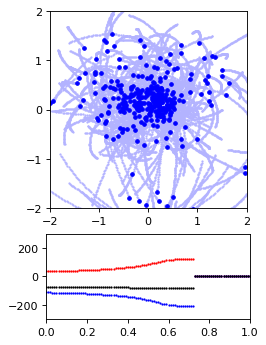

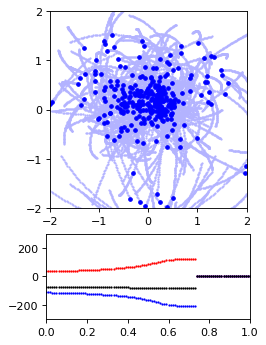

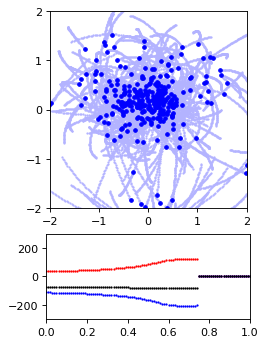

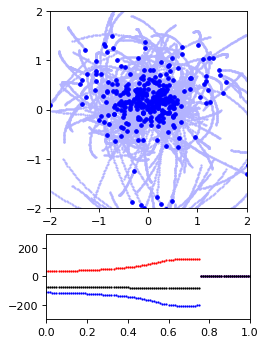

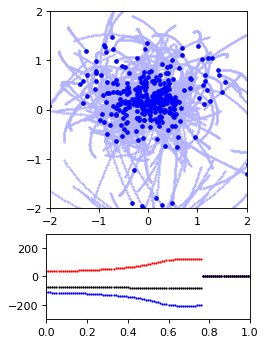

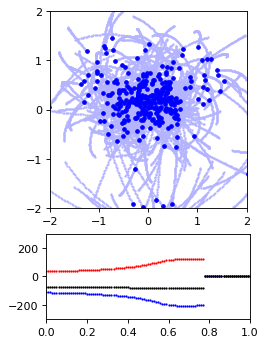

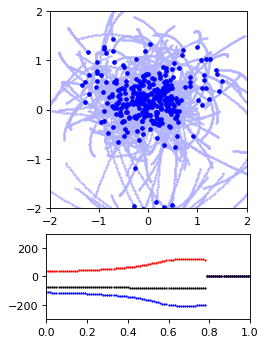

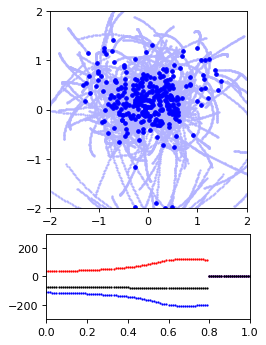

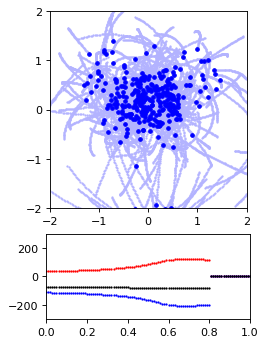

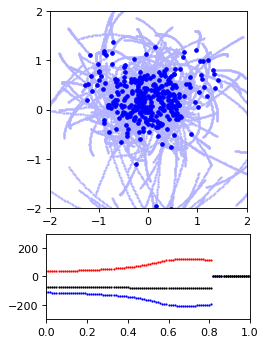

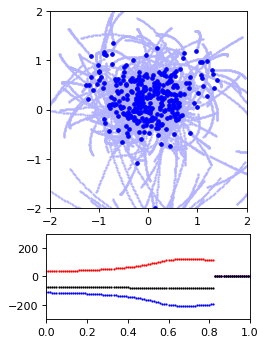

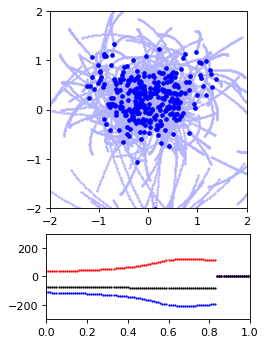

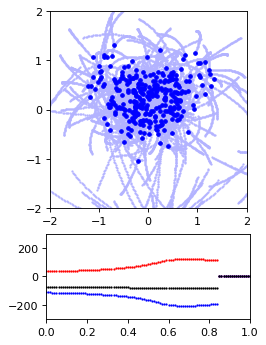

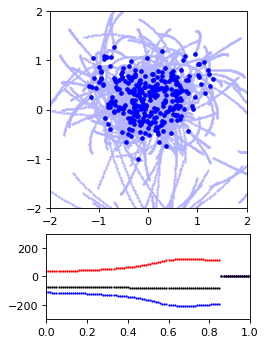

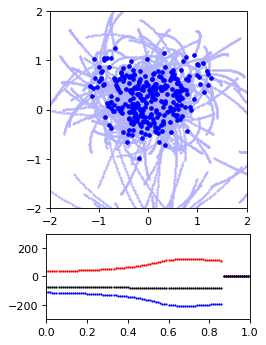

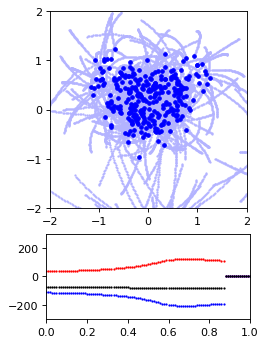

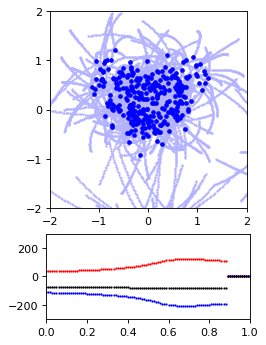

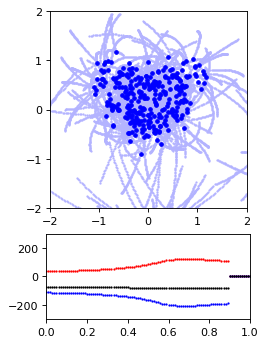

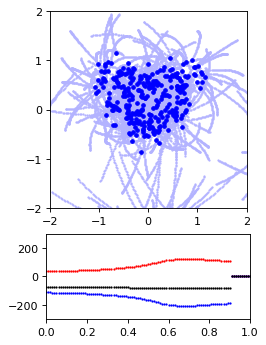

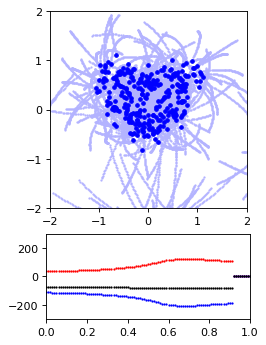

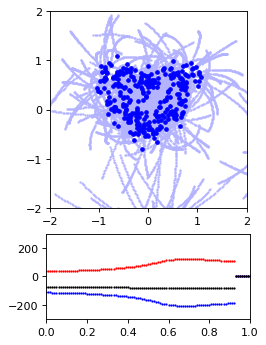

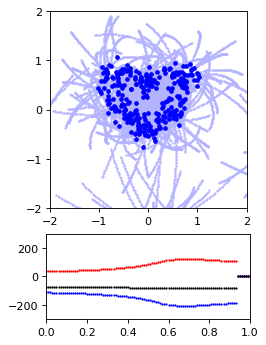

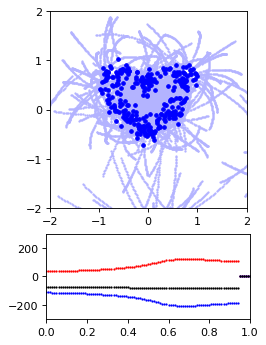

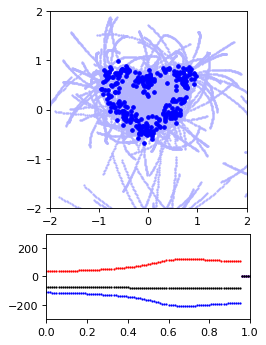

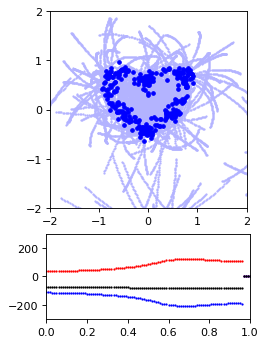

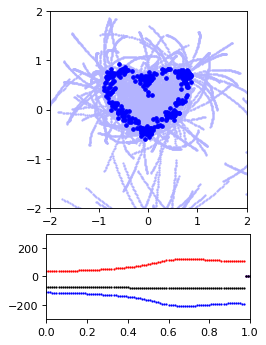

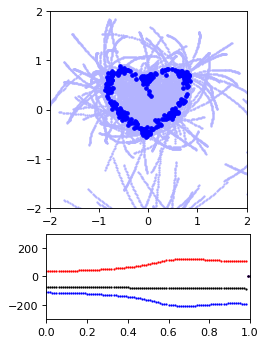

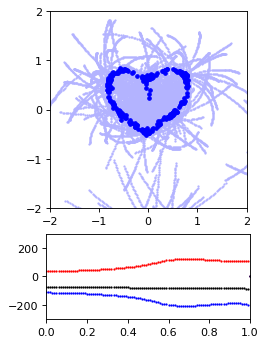

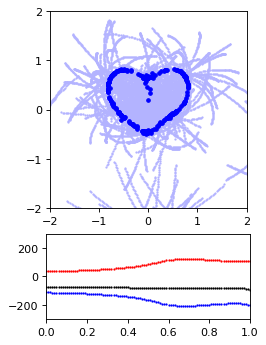

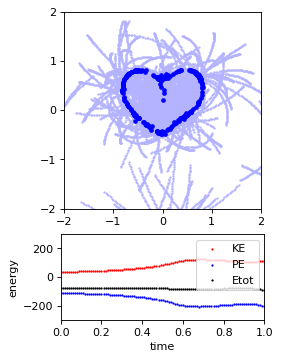

In [ ]:
!pip install jax jaxlib jaxopt matplotlib
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jaxopt import ScipyMinimize

"""
Create Your Own Differentiable N-body Simulation (With Python/JAX)
Philip Mocz (2025) @pmocz

Simulate orbits of stars interacting due to gravity.
The code evolves particles according to pairwise interactions following Newton's Law of Gravity.

Auto-differentiability allows for solving inverse problems!
E.g. find the initial velocities of particles that result in a target distribution at t=1.0
"""

# Global parameters
N = 360  # number of particles
t_end = 1.0  # time at which simulation ends
dt = 0.01  # timestep
softening = 0.1  # softening length
G = 1.0  # Newton's gravitational constant
Nt = int(jnp.ceil(t_end / dt))  # number of timesteps


@jax.jit
def get_acc(pos, mass):
    """
    Calculate the acceleration on each particle according to Newton's Law
    pos        is an N x 3 matrix of positions
    mass       is an N x 1 vector of masses
    acc        is an N x 3 matrix of accelerations
    """
    # positions r = [x,y,z] for all particles
    x = pos[:, 0:1]
    y = pos[:, 1:2]
    z = pos[:, 2:3]

    # matrix that stores all pairwise particle separations: r_j - r_i
    dx = x.T - x
    dy = y.T - y
    dz = z.T - z

    # matrix that stores 1/r^3 for all particle pairwise particle separations
    inv_r3 = (dx**2 + dy**2 + dz**2 + softening**2) ** (-1.5)

    # acceleration components
    ax = G * (dx * inv_r3) @ mass
    ay = G * (dy * inv_r3) @ mass
    az = G * (dz * inv_r3) @ mass

    # pack together the acceleration components
    acc = jnp.hstack((ax, ay, az))

    return acc


@jax.jit
def get_energy(pos, vel, mass):
    """
    Get kinetic energy (KE) and potential energy (PE) of simulation
    pos   is N x 3 matrix of positions
    vel   is N x 3 matrix of velocities
    mass  is an N x 1 vector of masses
    KE    is the kinetic energy of the system
    PE    is the potential energy of the system
    """
    # Kinetic Energy:
    KE = 0.5 * jnp.sum(jnp.sum(mass * vel**2))

    # Potential Energy:

    # positions r = [x,y,z] for all particles
    x = pos[:, 0:1]
    y = pos[:, 1:2]
    z = pos[:, 2:3]

    # matrix that stores all pairwise particle separations: r_j - r_i
    dx = x.T - x
    dy = y.T - y
    dz = z.T - z

    # matrix that stores 1/r for all particle pairwise particle separations
    inv_r = 1.0 / jnp.sqrt(dx**2 + dy**2 + dz**2)

    # sum over upper triangle, to count each interaction only once
    PE = G * jnp.sum(jnp.sum(jnp.triu(-(mass * mass.T) * inv_r, 1)))

    return KE, PE


@jax.jit
def leapfrog(i, state):
    """
    Take one timestep of the leapfrog integration scheme
    i          is the iteration number
    state      is a tuple of (pos, vel, acc, mass)
    """
    pos, vel, acc, mass = state

    # (1/2) kick
    vel += acc * dt / 2.0

    # drift
    pos += vel * dt

    # update accelerations
    acc = get_acc(pos, mass)

    # (1/2) kick
    vel += acc * dt / 2.0

    return pos, vel, acc, mass


@jax.jit
def do_simulation(pos, vel, mass, t):
    """
    Run the simulation for Nt timesteps
    pos        is an N x 3 matrix of positions
    vel        is an N x 3 matrix of velocities
    mass       is an N x 1 vector of masses
    t          is the time
    """

    # calculate initial gravitational accelerations
    acc = get_acc(pos, mass)

    # advance the simulation by Nt timesteps
    state = jax.lax.fori_loop(0, Nt, leapfrog, init_val=(pos, vel, acc, mass))
    pos, vel, acc, mass = state

    # update time
    t += Nt * dt

    return pos, vel, mass, t


@jax.jit
def loss_function(vel, pos, mass, target):
    """
    Loss function for optimization:
    Find initial conditions for velocity that results the target distribution
    Note: the 1st argument is the one that will be optimized over
    vel        is an N x 3 matrix of velocities
    pos        is an N x 3 matrix of positions
    mass       is an N x 1 vector of masses
    target     is an m x m matrix representing the target distribution
    """

    # Set initial condition
    t = 0
    np.random.seed(17)  # set the random number generator seed
    mass = 20.0 * jnp.ones((N, 1)) / N  # total mass of particles is 20
    pos = jnp.array(np.random.randn(N, 3))  # randomly selected positions and velocities

    # Convert to center-of-mass frame
    vel -= jnp.mean(mass * vel, 0) / jnp.mean(mass)

    # Carry out simulation
    pos, _, _, _ = do_simulation(pos, vel, mass, t)

    # Bin the resulting 2D positions and estimate the density
    pos2d = pos[:, 0:2].T

    m = target.shape[0]  # number of bins

    kde = jax.scipy.stats.gaussian_kde(pos2d)
    xlin = jnp.linspace(-2.0, 2.0, m)
    mx, my = jnp.meshgrid(xlin, xlin, indexing="ij")
    counts = kde.evaluate(jnp.array([mx.reshape(-1), my.reshape(-1)])).reshape((m, m))
    counts /= jnp.sum(counts)

    return jnp.sum((counts - target) ** 2)


def main():
    """N-body simulation with Inverse Problem
    Find initial velocities that result in a target distribution (a heart) at t = 1.0
    """

    # Set initial conditions
    np.random.seed(17)  # set the random number generator seed
    mass = 20.0 * jnp.ones((N, 1)) / N  # total mass of particles is 20
    pos = jnp.array(np.random.randn(N, 3))  # randomly selected positions and velocities
    vel = jnp.array(np.random.randn(N, 3))
    vel -= jnp.mean(mass * vel, 0) / jnp.mean(mass)

    # target distribution (heart-shape)
    n_bins = 80
    xlin = jnp.linspace(-2, 2, n_bins)
    xx, yy = jnp.meshgrid(xlin, xlin, indexing="ij")
    target = (xx**2 + yy**2 - 1.0) ** 3 - xx**2 * yy**3 < 0.0
    target = target.astype(float) / jnp.sum(target)

    # run the optimization:

    def print_step_info(intermediate_vel):
        print("loss:", loss_function(intermediate_vel, pos, mass, target))

    optimizer = ScipyMinimize(
        method="l-bfgs-b", fun=loss_function, tol=1e-8, callback=print_step_info
    )

    print("Optimizing initial conditions...")
    sol = optimizer.run(vel, pos, mass, target)
    print("Optimization complete.")

    # Setup the simulation with the optimized initial conditions
    np.random.seed(17)
    pos = jnp.array(np.random.randn(N, 3))
    mass = 20.0 * jnp.ones((N, 1)) / N
    vel = sol.params
    vel -= jnp.mean(mass * vel, 0) / jnp.mean(mass)
    acc = get_acc(pos, mass)

    # plot initial velocities as arrows
    fig = plt.figure(figsize=(4, 5), dpi=80)
    ax = fig.add_subplot(111)
    ax.quiver(pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1])
    plt.scatter(pos[:, 0], pos[:, 1], s=10, color="blue")
    ax.set(xlim=(-2, 2), ylim=(-2, 2))
    ax.set_aspect("equal", "box")
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Initial velocities")
    plt.savefig("heart-ics.png", dpi=240)
    plt.pause(1.0)

    # calculate initial energy of system
    KE, PE = get_energy(pos, vel, mass)

    # save energies, particle orbits for plotting trails
    pos_save = np.zeros((N, 3, Nt + 1))
    KE_save = np.zeros(Nt + 1)
    PE_save = np.zeros(Nt + 1)
    t_all = np.arange(Nt + 1) * dt
    pos_save[:, :, 0] = pos
    KE_save[0] = KE
    PE_save[0] = PE

    # switch on to plot in real time
    plot_realtime = True

    # prep figure
    fig = plt.figure(figsize=(4, 5), dpi=80)
    grid = plt.GridSpec(3, 1, wspace=0.0, hspace=0.3)
    ax1 = plt.subplot(grid[0:2, 0])
    ax2 = plt.subplot(grid[2, 0])

    # Simulation Main Loop
    for i in range(Nt):
        pos, vel, acc, mass = leapfrog(i, (pos, vel, acc, mass))

        # get energy of system
        KE, PE = get_energy(pos, vel, mass)

        # save energies, positions for plotting trail
        pos_save[:, :, i + 1] = pos
        KE_save[i + 1] = KE
        PE_save[i + 1] = PE

        # plot in real time
        if plot_realtime or (i == Nt - 1):
            plt.sca(ax1)
            plt.cla()
            xx = pos_save[:, 0, max(i - 50, 0) : i + 1]
            yy = pos_save[:, 1, max(i - 50, 0) : i + 1]
            plt.scatter(xx, yy, s=1, color=[0.7, 0.7, 1])
            plt.scatter(pos[:, 0], pos[:, 1], s=10, color="blue")
            ax1.set(xlim=(-2, 2), ylim=(-2, 2))
            ax1.set_aspect("equal", "box")
            ax1.set_xticks([-2, -1, 0, 1, 2])
            ax1.set_yticks([-2, -1, 0, 1, 2])

            plt.sca(ax2)
            plt.cla()
            plt.scatter(
                t_all, KE_save, color="red", s=1, label="KE" if i == Nt - 1 else ""
            )
            plt.scatter(
                t_all, PE_save, color="blue", s=1, label="PE" if i == Nt - 1 else ""
            )
            plt.scatter(
                t_all,
                KE_save + PE_save,
                color="black",
                s=1,
                label="Etot" if i == Nt - 1 else "",
            )
            ax2.set(xlim=(0, t_end), ylim=(-300, 300))
            ax2.set_aspect(0.0007)

            plt.pause(0.001)

    # add labels/legend
    plt.sca(ax2)
    plt.xlabel("time")
    plt.ylabel("energy")
    ax2.legend(loc="upper right")

    # Save figure
    plt.savefig("heart-nbody.png", dpi=240)
    plt.show()

    return


if __name__ == "__main__":
    main()

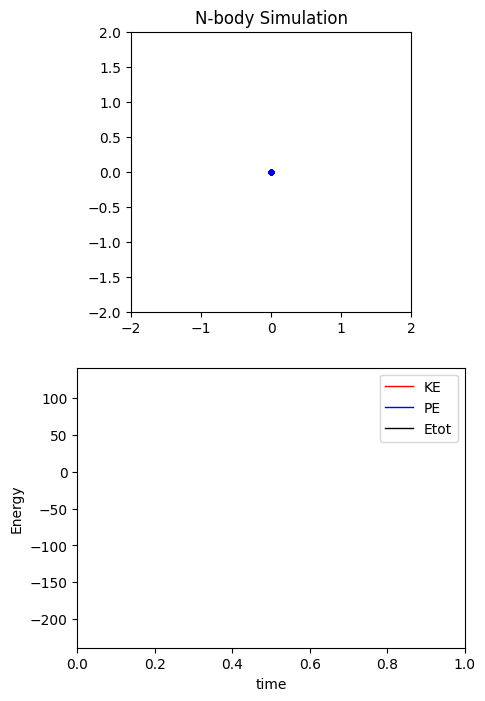

In [ ]:
!pip install jax jaxlib jaxopt matplotlib
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from jaxopt import ScipyMinimize

# Global parameters
N = 180  # reduced for speed
t_end = 1.0
dt = 0.01
softening = 0.1
G = 1.0
Nt = int(jnp.ceil(t_end / dt))


@jax.jit
def get_acc(pos, mass):
    x, y, z = pos[:, 0:1], pos[:, 1:2], pos[:, 2:3]
    dx, dy, dz = x.T - x, y.T - y, z.T - z
    inv_r3 = (dx**2 + dy**2 + dz**2 + softening**2) ** (-1.5)
    ax = G * (dx * inv_r3) @ mass
    ay = G * (dy * inv_r3) @ mass
    az = G * (dz * inv_r3) @ mass
    return jnp.hstack((ax, ay, az))


@jax.jit
def get_energy(pos, vel, mass):
    KE = 0.5 * jnp.sum(jnp.sum(mass * vel**2))
    x, y, z = pos[:, 0:1], pos[:, 1:2], pos[:, 2:3]
    dx, dy, dz = x.T - x, y.T - y, z.T - z
    inv_r = 1.0 / jnp.sqrt(dx**2 + dy**2 + dz**2 + 1e-5)
    PE = G * jnp.sum(jnp.sum(jnp.triu(-(mass * mass.T) * inv_r, 1)))
    return KE, PE


@jax.jit
def leapfrog(i, state):
    pos, vel, acc, mass = state
    vel += acc * dt / 2.0
    pos += vel * dt
    acc = get_acc(pos, mass)
    vel += acc * dt / 2.0
    return pos, vel, acc, mass


def run_simulation(pos, vel, mass):
    acc = get_acc(pos, mass)
    states = []
    KE_list, PE_list = [], []
    for i in range(Nt):
        pos, vel, acc, mass = leapfrog(i, (pos, vel, acc, mass))
        KE, PE = get_energy(pos, vel, mass)
        states.append(np.array(pos))  # make sure it's numpy
        KE_list.append(float(KE))
        PE_list.append(float(PE))
    return np.array(states), KE_list, PE_list


def main():
    np.random.seed(17)
    mass = 20.0 * jnp.ones((N, 1)) / N
    pos = jnp.array(np.random.randn(N, 3))
    vel = jnp.array(np.random.randn(N, 3))
    vel -= jnp.mean(mass * vel, 0) / jnp.mean(mass)

    # Run simulation and collect trajectory
    states, KE_list, PE_list = run_simulation(pos, vel, mass)  # shape: (Nt, N, 3)

    # Set up figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8))

    scat = ax1.scatter([], [], s=10, color="blue")
    ax1.set_xlim(-2, 2)
    ax1.set_ylim(-2, 2)
    ax1.set_aspect("equal")
    ax1.set_title("N-body Simulation")

    line_ke, = ax2.plot([], [], "r-", lw=1, label="KE")
    line_pe, = ax2.plot([], [], "b-", lw=1, label="PE")
    line_tot, = ax2.plot([], [], "k-", lw=1, label="Etot")
    ax2.set_xlim(0, t_end)
    ax2.set_ylim(min(PE_list) * 1.1, max(KE_list) * 1.1)
    ax2.set_xlabel("time")
    ax2.set_ylabel("Energy")
    ax2.legend()

    def init():
        scat.set_offsets(np.zeros((N, 2)))  # initialize with zeros
        line_ke.set_data([], [])
        line_pe.set_data([], [])
        line_tot.set_data([], [])
        return scat, line_ke, line_pe, line_tot

    def update(frame):
        pos = states[frame][:, :2]  # (N, 2) positions
        scat.set_offsets(pos)

        t = np.arange(frame + 1) * dt
        line_ke.set_data(t, KE_list[: frame + 1])
        line_pe.set_data(t, PE_list[: frame + 1])
        line_tot.set_data(t, (np.array(KE_list) + np.array(PE_list))[: frame + 1])
        return scat, line_ke, line_pe, line_tot

    ani = FuncAnimation(
        fig, update, frames=Nt, init_func=init, blit=True, interval=30, repeat=False
    )

    plt.show()


if __name__ == "__main__":
    main()


✅ Animation saved as nbody.gif


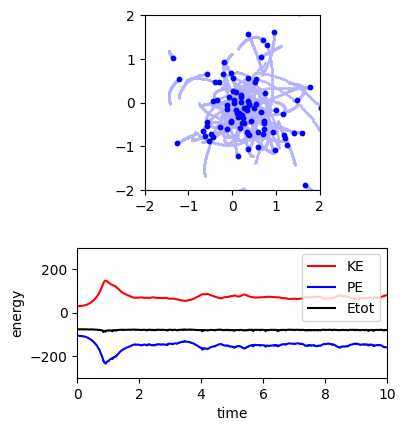

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

"""
Create Your Own N-body Simulation (With Python)
Philip Mocz (2020) Princeton University, @PMocz
"""





def getAcc(pos, mass, G, softening):
    """Calculate gravitational acceleration"""
    x, y, z = pos[:, 0:1], pos[:, 1:2], pos[:, 2:3]
    dx, dy, dz = x.T - x, y.T - y, z.T - z
    inv_r3 = dx**2 + dy**2 + dz**2 + softening**2
    inv_r3[inv_r3 > 0] = inv_r3[inv_r3 > 0] ** (-1.5)
    ax = G * (dx * inv_r3) @ mass
    ay = G * (dy * inv_r3) @ mass
    az = G * (dz * inv_r3) @ mass
    return np.hstack((ax, ay, az))


def getEnergy(pos, vel, mass, G):
    """Calculate KE and PE"""
    KE = 0.5 * np.sum(np.sum(mass * vel**2))
    x, y, z = pos[:, 0:1], pos[:, 1:2], pos[:, 2:3]
    dx, dy, dz = x.T - x, y.T - y, z.T - z
    inv_r = np.sqrt(dx**2 + dy**2 + dz**2)
    inv_r[inv_r > 0] = 1.0 / inv_r[inv_r > 0]
    PE = G * np.sum(np.sum(np.triu(-(mass * mass.T) * inv_r, 1)))
    return KE, PE


def main():
    """N-body simulation with animated gif output"""

    # Parameters
    N, t, tEnd, dt = 100, 0, 10.0, 0.01
    softening, G = 0.1, 1.0

    # Initial conditions
    np.random.seed(17)
    mass = 20.0 * np.ones((N, 1)) / N
    pos = np.random.randn(N, 3)
    vel = np.random.randn(N, 3)
    vel -= np.mean(mass * vel, 0) / np.mean(mass)
    acc = getAcc(pos, mass, G, softening)

    # Timesteps
    Nt = int(np.ceil(tEnd / dt))
    pos_save = np.zeros((N, 3, Nt + 1))
    pos_save[:, :, 0] = pos

    KE_save, PE_save = np.zeros(Nt + 1), np.zeros(Nt + 1)
    KE_save[0], PE_save[0] = getEnergy(pos, vel, mass, G)

    # Run simulation
    for i in range(Nt):
        vel += acc * dt / 2.0
        pos += vel * dt
        acc = getAcc(pos, mass, G, softening)
        vel += acc * dt / 2.0
        t += dt
        KE, PE = getEnergy(pos, vel, mass, G)
        pos_save[:, :, i + 1], KE_save[i + 1], PE_save[i + 1] = pos, KE, PE

    # --- Animation ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 5), dpi=100)
    t_all = np.arange(Nt + 1) * dt

    def update(frame):
        ax1.clear()
        ax2.clear()
        xx, yy = pos_save[:, 0, max(frame - 50, 0):frame + 1], pos_save[:, 1, max(frame - 50, 0):frame + 1]
        ax1.scatter(xx, yy, s=1, color=[0.7, 0.7, 1])
        ax1.scatter(pos_save[:, 0, frame], pos_save[:, 1, frame], s=10, color="blue")
        ax1.set(xlim=(-2, 2), ylim=(-2, 2))
        ax1.set_aspect("equal")

        ax2.plot(t_all[:frame], KE_save[:frame], color="red", label="KE")
        ax2.plot(t_all[:frame], PE_save[:frame], color="blue", label="PE")
        ax2.plot(t_all[:frame], KE_save[:frame] + PE_save[:frame], color="black", label="Etot")
        ax2.set(xlim=(0, tEnd), ylim=(-300, 300))
        ax2.set_aspect(0.007)
        ax2.set_xlabel("time")
        ax2.set_ylabel("energy")
        ax2.legend(loc="upper right")

    ani = FuncAnimation(fig, update, frames=Nt, interval=20)
    ani.save("nbody.gif", writer=PillowWriter(fps=30))
    print("✅ Animation saved as nbody.gif")


if __name__ == "__main__":
    main()
